In [1]:
import bilby
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def bbh_lensing(frequency_array, mass_1, mass_2, a_1, a_2, tilt_1, tilt_2, phi_12, phi_jl, 
                        luminosity_distance, theta_jn, phase, 
                        delta_theta_jn, delta_phase, delta_t, rel_mu, 
                        **kwargs):

    # plus waveform
    wf_plus = bilby.gw.source.lal_binary_black_hole(
        frequency_array=frequency_array, mass_1=mass_1, mass_2=mass_2,
        luminosity_distance=luminosity_distance, theta_jn=theta_jn, phase=phase,
        a_1=a_1, a_2=a_2, tilt_1=tilt_1, tilt_2=tilt_2, phi_12=phi_12,
        phi_jl=phi_jl, **kwargs)
    hplus_plus = wf_plus['plus']
    hcross_plus = wf_plus['cross']

    # minus waveform, with different parameters
    wf_minus = bilby.gw.source.lal_binary_black_hole(
        frequency_array=frequency_array, mass_1=mass_1, mass_2=mass_2,
        luminosity_distance=luminosity_distance, theta_jn=theta_jn+delta_theta_jn, phase=phase+delta_phase,
        a_1=a_1, a_2=a_2, tilt_1=tilt_1, tilt_2=tilt_2, phi_12=phi_12,
        phi_jl=phi_jl, **kwargs)
    hplus_minus = wf_minus['plus']
    hcross_minus = wf_minus['cross']

    # phase shift due to time delay between the two images
    F_arr = np.exp(- 1j * frequency_array * delta_t)
    
    # full waveform
    hplus = hplus_plus + np.sqrt(np.abs(rel_mu)) * F_arr * hplus_minus
    hcross = hcross_plus + np.sqrt(np.abs(rel_mu)) * F_arr * hcross_minus

    return {"plus": hplus, "cross": hcross}

In [3]:
# define injection parameters
injection_parameters = dict(
    mass_1=60,
    mass_2=30,
    a_1=0.8,
    a_2=0.5,
    tilt_1=0.5,
    tilt_2=1.0,
    phi_12=1.7,
    phi_jl=0.3,
    luminosity_distance=4000.0,
    theta_jn=2,
    psi=2.659,
    phase=1.3,
    geocent_time=1126259642.413,
    ra=1.375,
    dec=-1.2108,
    delta_theta_jn=1,
    delta_phase=0.1,
    delta_t=0.5,
    rel_mu=1.5
)

21:34 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: __main__.bbh_lensing
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/bilby/gw/source.py:528: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


Text(0.5, 0, 'log(Frequency)')

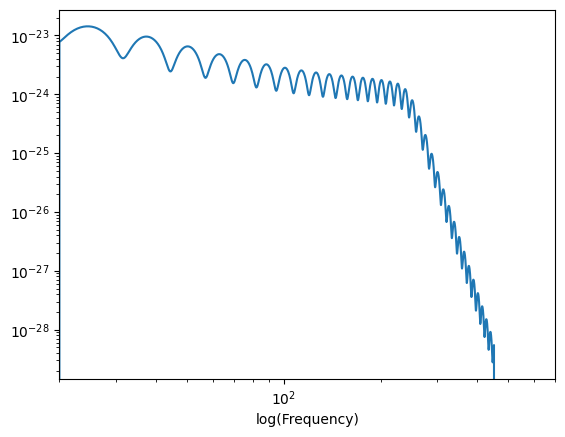

In [4]:
# check how waveform plots out
duration = 4
sampling_frequency = 2048
outdir = "outdir_theta_phi"
label = "bbh_lensing_model"

waveform_arguments = dict(
    waveform_approximant="IMRPhenomPv2",
    reference_frequency=20,
    minimum_frequency=20,
)
wf_generator = bilby.gw.waveform_generator.WaveformGenerator(
    duration=duration,
    sampling_frequency=sampling_frequency,
    start_time=injection_parameters["geocent_time"] - 2,
    frequency_domain_source_model=bbh_lensing,
    time_domain_source_model=None,
    parameters=None,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments,
)

strains = wf_generator.frequency_domain_strain(parameters=injection_parameters)
hplus = strains['plus']
hcross = strains['cross']
frequencies = wf_generator.frequency_array

plt.loglog(frequencies, np.abs(hplus))
plt.xlim(20,700)
plt.xlabel("log(Frequency)")

In [5]:
# set up interferometers
ifos = bilby.gw.detector.InterferometerList(["H1", "L1"])
ifos.set_strain_data_from_power_spectral_densities(
    sampling_frequency=sampling_frequency,
    duration=duration,
    start_time=injection_parameters["geocent_time"] - 2,
)
ifos.inject_signal(
    waveform_generator=wf_generator, parameters=injection_parameters
)

21:34 bilby INFO    : Injected signal in H1:
21:34 bilby INFO    :   optimal SNR = 10.91
21:34 bilby INFO    :   matched filter SNR = 10.81-0.24j
21:34 bilby INFO    :   mass_1 = 60
21:34 bilby INFO    :   mass_2 = 30
21:34 bilby INFO    :   a_1 = 0.8
21:34 bilby INFO    :   a_2 = 0.5
21:34 bilby INFO    :   tilt_1 = 0.5
21:34 bilby INFO    :   tilt_2 = 1.0
21:34 bilby INFO    :   phi_12 = 1.7
21:34 bilby INFO    :   phi_jl = 0.3
21:34 bilby INFO    :   luminosity_distance = 4000.0
21:34 bilby INFO    :   theta_jn = 2
21:34 bilby INFO    :   psi = 2.659
21:34 bilby INFO    :   phase = 1.3
21:34 bilby INFO    :   geocent_time = 1126259642.413
21:34 bilby INFO    :   ra = 1.375
21:34 bilby INFO    :   dec = -1.2108
21:34 bilby INFO    :   delta_theta_jn = 1
21:34 bilby INFO    :   delta_phase = 0.1
21:34 bilby INFO    :   delta_t = 0.5
21:34 bilby INFO    :   rel_mu = 1.5
21:34 bilby INFO    : Injected signal in L1:
21:34 bilby INFO    :   optimal SNR = 8.74
21:34 bilby INFO    :   match

[{'plus': array([0.+0.j, 0.-0.j, 0.-0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j]),
  'cross': array([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j])},
 {'plus': array([0.+0.j, 0.-0.j, 0.-0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j]),
  'cross': array([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j])}]

In [6]:
# define priors, only sample over delta_theta_jn and delta_phase
priors = bilby.gw.prior.BBHPriorDict()
for key in [
    "a_1",
    "a_2",
    "tilt_1",
    "tilt_2",
    "phi_12",
    "phi_jl",
    "phase",
    "theta_jn",
    "psi",
    "luminosity_distance",
    "ra",
    "dec",
    "geocent_time",
    "delta_t",
    "rel_mu",
]:
    priors[key] = injection_parameters[key]

q = injection_parameters['mass_2'] / injection_parameters['mass_1']
total_mass = injection_parameters['mass_2'] + injection_parameters['mass_1']
eta = q / (1 + q)**2
priors['chirp_mass'] = eta**(3/5) * total_mass
priors['mass_ratio'] = q

priors["delta_theta_jn"] = bilby.core.prior.Uniform(
    name="delta_theta_jn", minimum=0, maximum=1, unit="rad"
)
priors["delta_phase"] = bilby.core.prior.Uniform(
    name="delta_phase", minimum=0, maximum=1, unit="rad"
)

21:34 bilby INFO    : No prior given, using default BBH priors in /Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/bilby/gw/prior_files/precessing_spins_bbh.prior.


In [7]:
likelihood = bilby.gw.GravitationalWaveTransient(
    interferometers=ifos, waveform_generator=wf_generator
)

In [8]:
result = bilby.run_sampler(
    likelihood=likelihood,
    priors=priors,
    sampler="dynesty",
    outdir="outdir_theta_phi",
    nlive=500,
    injection_parameters=injection_parameters,
    label="bbh_lensing",
)
result.plot_corner()

21:34 bilby INFO    : Running for label 'bbh_lensing', output will be saved to 'outdir_theta_phi'
21:34 bilby INFO    : Using lal version 7.5.0
21:34 bilby INFO    : Using lal git version Branch: None;Tag: lalsuite-v7.22;Id: 5c23000593918e5e4ef2ff809eccc1722b5d0795;;Builder: Duncan Macleod <duncan.macleod@ligo.org>;Repository status: CLEAN: All modifications committed
21:34 bilby INFO    : Using lalsimulation version 5.4.0
21:34 bilby INFO    : Using lalsimulation git version Branch: None;Tag: lalsuite-v7.22;Id: 5c23000593918e5e4ef2ff809eccc1722b5d0795;;Builder: Duncan Macleod <duncan.macleod@ligo.org>;Repository status: CLEAN: All modifications committed


21:34 bilby INFO    : Analysis priors:
21:34 bilby INFO    : delta_theta_jn=Uniform(minimum=0, maximum=1, name='delta_theta_jn', latex_label='delta_theta_jn', unit='rad', boundary=None)
21:34 bilby INFO    : delta_phase=Uniform(minimum=0, maximum=1, name='delta_phase', latex_label='delta_phase', unit='rad', boundary=None)
21:34 bilby INFO    : mass_1=Constraint(minimum=5, maximum=100, name='mass_1', latex_label='$m_1$', unit=None)
21:34 bilby INFO    : mass_2=Constraint(minimum=5, maximum=100, name='mass_2', latex_label='$m_2$', unit=None)
21:34 bilby INFO    : mass_ratio=0.5
21:34 bilby INFO    : chirp_mass=36.50186051359234
21:34 bilby INFO    : luminosity_distance=4000.0
21:34 bilby INFO    : dec=-1.2108
21:34 bilby INFO    : ra=1.375
21:34 bilby INFO    : theta_jn=2
21:34 bilby INFO    : psi=2.659
21:34 bilby INFO    : phase=1.3
21:34 bilby INFO    : a_1=0.8
21:34 bilby INFO    : a_2=0.5
21:34 bilby INFO    : tilt_1=0.5
21:34 bilby INFO    : tilt_2=1.0
21:34 bilby INFO    : phi_12=

5373it [00:01, -0.65it/s, bound:110 nc:  1 ncall:8.4e+04 eff:7.0% logz-ratio=479.28+/-0.12 dlogz:0.000>0.1]

21:34 bilby INFO    : Run interrupted by signal 2: checkpoint and exit on 130


21:34 bilby INFO    : Written checkpoint file outdir_theta_phi/bbh_lensing_resume.pickle


SystemExit: 130

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
